# 二、高级监督学习


In [13]:
#导入模块
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 数据集
from sklearn.datasets import load_iris, load_digits, make_blobs, make_regression, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 高级监督学习模型
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# 评估指标
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')
#解决中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']  
plt.rcParams['axes.unicode_minus'] = False    

## 1.支持向量机-分类问题
SVM 的目标是找到一个最优超平面，使两类样本到超平面的间隔最大。在线性不可分的情况下，通过核函数将数据映射到高维空间，使其线性可分。<br/>
下面从核函数层面解析模型。

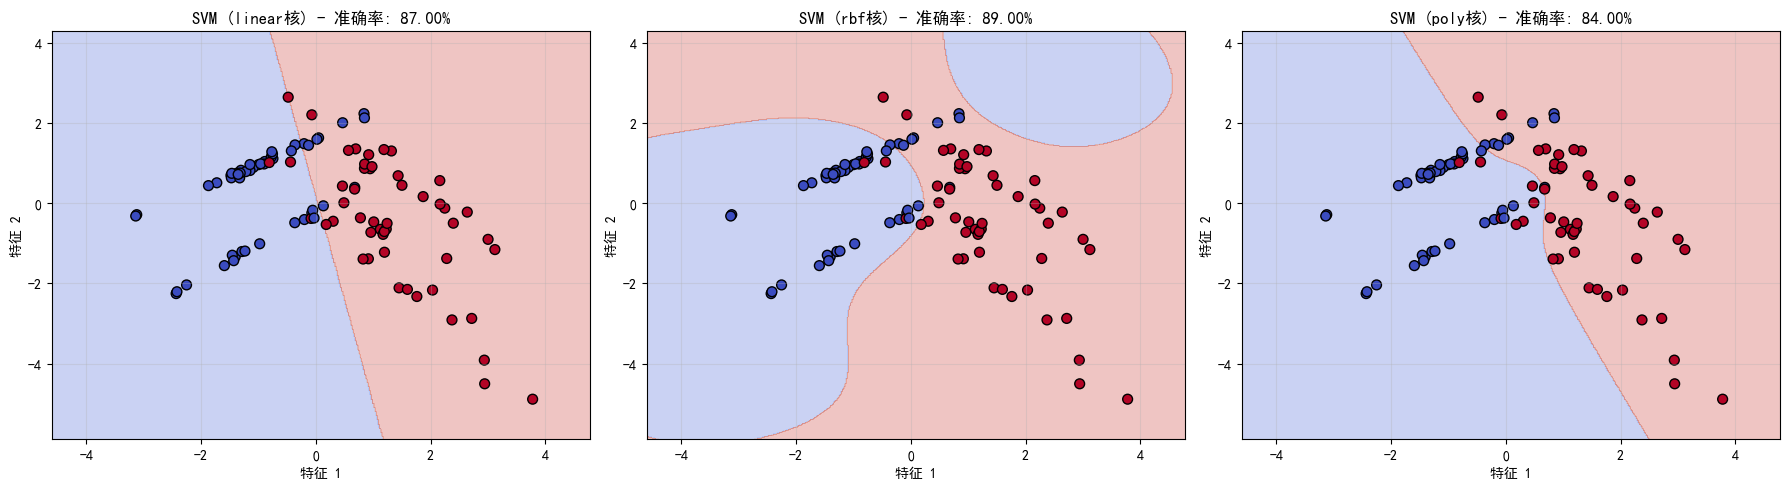

In [14]:
#生成数据集
X_clf, y_clf = make_classification(
    n_samples=500,
    n_features=2,        
    n_informative=2,
    n_redundant=0,
    random_state=42
)
# 1. 数据准备
X_train, X_test, y_train, y_test = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

# 2. 训练不同核函数的 SVM
kernels = ['linear', 'rbf', 'poly']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, kernel in enumerate(kernels):
    svm = SVC(kernel=kernel, random_state=42)
    svm.fit(X_train, y_train)
    acc = accuracy_score(y_test, svm.predict(X_test))
    
    # 决策边界
    x_min, x_max = X_clf[:, 0].min() - 1, X_clf[:, 0].max() + 1
    y_min, y_max = X_clf[:, 1].min() - 1, X_clf[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    Z = svm.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    axes[i].contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    axes[i].scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolors='k', 
                    cmap=plt.cm.coolwarm, s=50)
    axes[i].set_title(f'SVM ({kernel}核) - 准确率: {acc:.2%}')
    axes[i].set_xlabel('特征 1')
    axes[i].set_ylabel('特征 2')
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

总结：
* 线性核：决策边界为直线，与逻辑回归类似
* RBF 核（高斯核）：能拟合复杂的非线性边界
* 多项式核：用多项式函数映射，边界更光滑

## 2.随机森林
随机森林是集成学习中 Bagging 思想的代表：构建多棵决策树，每棵树使用随机样本子集和随机特征子集，最终通过投票（分类）或平均（回归）得到结果，显著降低单棵树的过拟合风险。<br/>
模型解析：<br/>
下述代码使用sklearn 手写数字数据集 load_digits()，将 8×8 手写数字图片展平，得到64个像素特征；以像素特征作为模型输入，搭建随机森林模型完成 0-9 数字的多分类识别。通过特征重要性分析哪些像素位置对识别起到关键作用，利用混淆矩阵观察模型各类数字的识别正误情况。

随机森林准确率: 97.22%


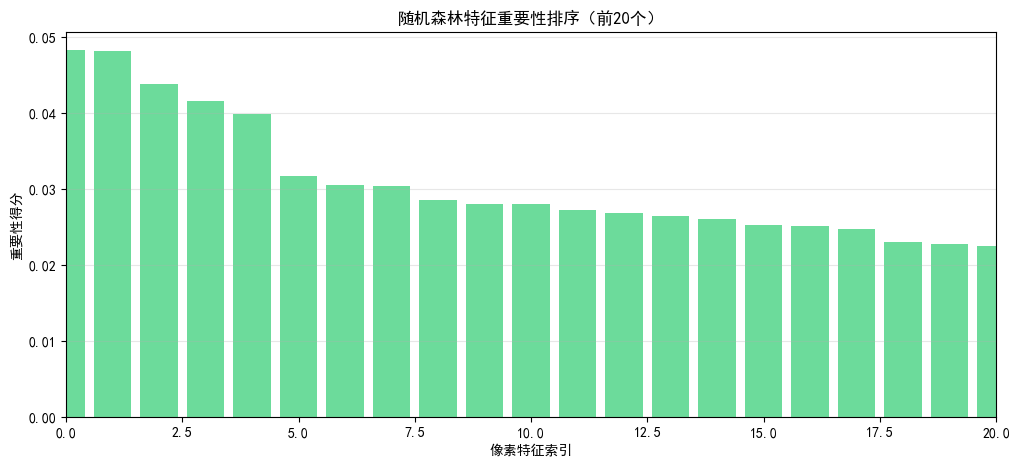

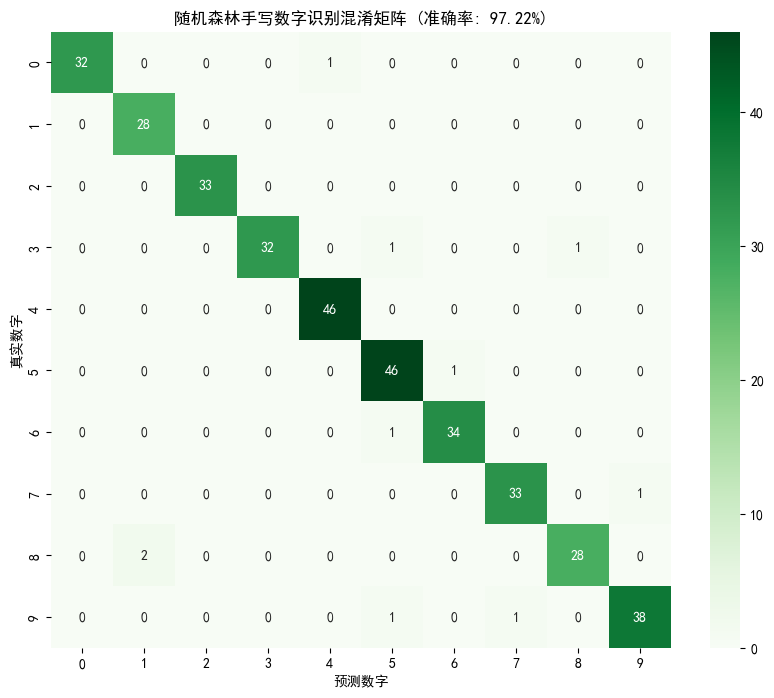

In [15]:
# 1. 使用手写数字数据集（十分类）
digits = load_digits()
X_digits = digits.data
y_digits = digits.target

X_train, X_test, y_train, y_test = train_test_split(X_digits, y_digits, 
                                                    test_size=0.2, random_state=42)

# 2. 训练随机森林
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

# 3. 评估
y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"随机森林准确率: {acc:.2%}")

# 4. 可视化1：特征重要性
plt.figure(figsize=(12, 5))
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
plt.bar(range(X_digits.shape[1]), importances[indices], color='#2ecc71', alpha=0.7)
plt.xlabel('像素特征索引')
plt.ylabel('重要性得分')
plt.title('随机森林特征重要性排序（前20个）')
plt.xlim(0, 20)  # 只显示前20个特征
plt.grid(alpha=0.3, axis='y')
plt.show()

# 5. 可视化2：混淆矩阵
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=digits.target_names,
            yticklabels=digits.target_names)
plt.xlabel('预测数字')
plt.ylabel('真实数字')
plt.title(f'随机森林手写数字识别混淆矩阵 (准确率: {acc:.2%})')
plt.show()

总结：
* 随机森林通过 "多棵树投票" 降低方差，抗过拟合能力强
* 可以输出特征重要性，解释哪些像素对数字识别贡献最大

## 3.梯度提升
梯度提升是Boosting 思想的代表：串行地训练多个弱学习器，每一轮新的学习器都去修正前面所有学习器的预测误差，逐步减小偏差。<br/>
下面的模型以手写数字执行多分类任务，搭建梯度提升分类模型；固定学习率、树最大深度，控制变量研究弱决策树数量对分类精度的影响，通过绘制准确率变化曲线，分析模型收敛特性与过拟合风险。

梯度提升准确率: 96.94%


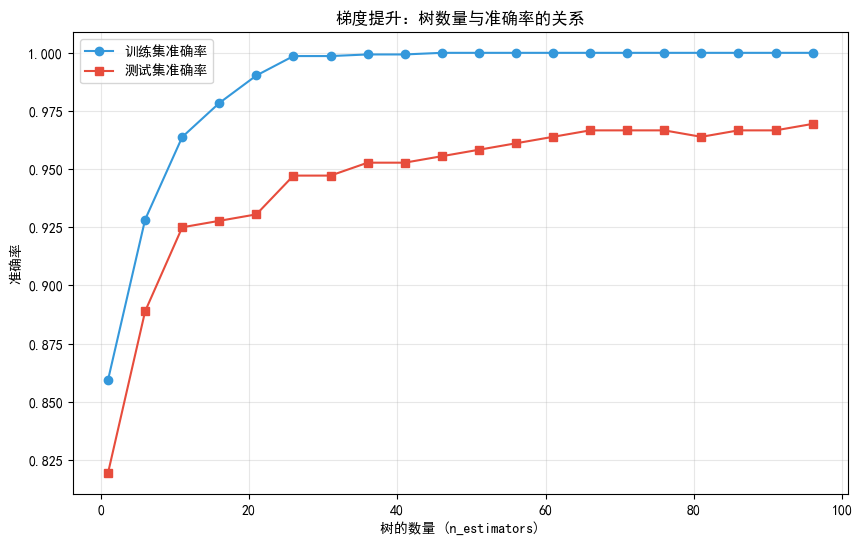

In [16]:
# 1. 数据准备（手写数字）
X_train, X_test, y_train, y_test = train_test_split(X_digits, y_digits, 
                                                    test_size=0.2, random_state=42)

# 2. 训练梯度提升
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, 
                                max_depth=3, random_state=42)
gb.fit(X_train, y_train)

# 3. 评估
y_pred = gb.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"梯度提升准确率: {acc:.2%}")

# 4. 可视化：训练过程中的准确率变化
train_scores = []
test_scores = []
for n_estimators in range(1, 101, 5):
    gb_temp = GradientBoostingClassifier(n_estimators=n_estimators, 
                                         learning_rate=0.1, max_depth=3, random_state=42)
    gb_temp.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, gb_temp.predict(X_train)))
    test_scores.append(accuracy_score(y_test, gb_temp.predict(X_test)))

plt.figure(figsize=(10, 6))
plt.plot(range(1, 101, 5), train_scores, 'o-', label='训练集准确率', color='#3498db')
plt.plot(range(1, 101, 5), test_scores, 's-', label='测试集准确率', color='#e74c3c')
plt.xlabel('树的数量 (n_estimators)')
plt.ylabel('准确率')
plt.title('梯度提升：树数量与准确率的关系')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

总结：<br/>
* 梯度提升是串行集成学习：不断训练新树去修正前一轮模型的预测误差。
* 树数量过少：模型欠拟合，容量不足；
* 树数量过多：容易持续拟合训练集噪声，引发过拟合。